# RQ1 — Can NLP automatically identify eligibility requirements in art open calls?

**Task.** Classify each sentence ("chunk") of an open call's `requirements_text_en` into one of 9 eligibility labels:
`RESIDENCE`, `NATIONALITY`, `AGE`, `DISCIPLINE`, `CAREER_STAGE`, `EDUCATION`, `STUDENT_STATUS`, `OTHER_ELIGIBILITY`, `NONE`
(definitions and edge-case rules: `ANNOTATION_GUIDELINES.md`).

**Data.** `dataset/labels/eligibility_annotations.csv` — 678 labeled chunks from 217 opportunities, 15–194 chunks per class, from two annotation rounds (round 2 human-reviewed in part, Cohen's kappa 0.675 — see `ANNOTATION_GUIDELINES.md` §6).

**Validation.** 5-fold `StratifiedGroupKFold`, grouped by opportunity, so no call's chunks are split across train and test.
Headline metric: macro-F1, which weights every class equally despite the imbalance.

**Models**, each compared on the same folds:

| # | Model | Role |
|---|---|---|
| 1 | TF-IDF + Logistic Regression | baseline, product candidate |
| 2 | TF-IDF + Linear SVM | product candidate |
| 3 | Sentence embeddings (`bge-base-en-v1.5`) + Logistic Regression | product candidate |
| 4 | OpenAI LLM, few-shot | reference point only, not a product candidate |

The baseline's error analysis comes right after model 1: it drove a label audit and the removal of heading chunks (`ANNOTATION_GUIDELINES.md` §6), and it explains why model 3 was expected to help.


In [1]:
import os

import pandas as pd

REPO_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(REPO_ROOT, "dataset", "labels", "eligibility_annotations.csv")

df = pd.read_csv(DATA_PATH)
df.shape

(678, 6)

In [2]:
df["label"].value_counts()

label
NONE                 194
OTHER_ELIGIBILITY    137
DISCIPLINE           100
RESIDENCE             71
CAREER_STAGE          69
STUDENT_STATUS        36
NATIONALITY           31
AGE                   25
EDUCATION             15
Name: count, dtype: int64

In [3]:
df.groupby("opportunity_id").size().sort_values(ascending=False).head(10)

opportunity_id
mondriaan_fund_e52bef22781c                    22
mondriaan_fund_bccb4029c0d9                    16
national_culture_fund_bulgaria_8fca12fac738    15
kulturdirektoratet_norway_e1b48f36972d         14
kunsten_be_flanders_6f9b625b869d               14
kulturdirektoratet_norway_25c45f0fbcb7         14
creative_ireland_b4833a165cef                  12
fpu_slovakia_7d1dec061d0c                      11
dgartes_portugal_111bdc1e2ebf                  10
dansateliers_rotterdam_e3404a6adf78             9
dtype: int64

In [4]:
# 5 folds, grouped by opportunity so no call's chunks split across train/test
from sklearn.model_selection import StratifiedGroupKFold

X = df["chunk_text"]
y = df["label"]
groups = df["opportunity_id"]

# needs both: GroupKFold alone ignores the 9-class imbalance, StratifiedKFold alone
# would leak an opportunity's shared phrasing across train/test
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
all_labels = set(y.unique())

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    train_groups = set(groups.iloc[train_idx])   # distinct opportunities in train
    test_groups = set(groups.iloc[test_idx])     # distinct opportunities in test
    overlap = train_groups & test_groups          # opportunities present on both sides
    assert not overlap, f"fold {fold}: group leakage on {overlap}"

    # smallest classes (AGE=11, EDUCATION=12) may still miss a fold's test split
    missing = all_labels - set(y.iloc[test_idx])
    print(f"fold {fold}: train={len(train_idx):3d}  test={len(test_idx):3d}  "
          f"missing_from_test={sorted(missing) or 'none'}")

fold 0: train=542  test=136  missing_from_test=none
fold 1: train=542  test=136  missing_from_test=none
fold 2: train=542  test=136  missing_from_test=none
fold 3: train=543  test=135  missing_from_test=none
fold 4: train=543  test=135  missing_from_test=none


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

X_text = df[["chunk_text"]]  # DataFrame, not Series — ColumnTransformer needs a column name to select

baseline = Pipeline([
    # single-column selector: ColumnTransformer hands TfidfVectorizer a 1D array when given a bare column name
    ("features", ColumnTransformer([("tfidf", TfidfVectorizer(), "chunk_text")])),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

param_grid = {
    "features__tfidf__ngram_range": [(1, 1), (1, 2)],
    "features__tfidf__min_df": [1, 2, 3],
    "clf__C": [0.1, 1, 10],
}

# scoring=f1_macro, not accuracy — every class weighted equally despite the 6.5x imbalance
grid = GridSearchCV(baseline, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
grid.fit(X_text, y, groups=groups)

print("best params:", grid.best_params_)
print("best macro-F1 (mean over folds):", grid.best_score_)

best params: {'clf__C': 1, 'features__tfidf__min_df': 1, 'features__tfidf__ngram_range': (1, 1)}
best macro-F1 (mean over folds): 0.7067678240211154


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

# out-of-fold predictions for the whole corpus, using the best hyperparameters found above
y_pred = cross_val_predict(grid.best_estimator_, X_text, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, y_pred))

# ANNOTATION_GUIDELINES.md §2 menu order, for a readable confusion matrix
LABEL_ORDER = ["RESIDENCE", "NATIONALITY", "AGE", "DISCIPLINE", "CAREER_STAGE",
               "EDUCATION", "STUDENT_STATUS", "OTHER_ELIGIBILITY", "NONE"]

cm = confusion_matrix(y, y_pred, labels=LABEL_ORDER)
pd.DataFrame(cm, index=LABEL_ORDER, columns=LABEL_ORDER)

                   precision    recall  f1-score   support

              AGE       0.88      0.88      0.88        25
     CAREER_STAGE       0.75      0.78      0.77        69
       DISCIPLINE       0.63      0.72      0.67       100
        EDUCATION       0.88      0.47      0.61        15
      NATIONALITY       0.72      0.74      0.73        31
             NONE       0.65      0.74      0.70       194
OTHER_ELIGIBILITY       0.70      0.55      0.61       137
        RESIDENCE       0.71      0.69      0.70        71
   STUDENT_STATUS       0.84      0.72      0.78        36

         accuracy                           0.70       678
        macro avg       0.75      0.70      0.72       678
     weighted avg       0.70      0.70      0.69       678



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,OTHER_ELIGIBILITY,NONE
RESIDENCE,49,4,0,3,1,0,1,5,8
NATIONALITY,1,23,0,3,1,0,0,1,2
AGE,0,0,22,2,0,0,0,0,1
DISCIPLINE,2,2,0,72,6,0,0,3,15
CAREER_STAGE,1,0,2,6,54,0,1,1,4
EDUCATION,0,0,0,2,2,7,1,1,2
STUDENT_STATUS,0,1,1,1,2,1,26,0,4
OTHER_ELIGIBILITY,8,0,0,11,2,0,1,75,40
NONE,8,2,0,14,4,0,1,21,144


In [8]:
# Known limitations of this TF-IDF baseline behind the NONE <-> DISCIPLINE errors
# (bare-heading chunks, a third cause, were removed from the data - ANNOTATION_GUIDELINES.md SS6):
#  1. arts vocabulary in non-constraint sentences - project/delivery descriptions
#     ("work with ... arts, cultural or creative organisations") are NONE but share
#     DISCIPLINE's words; bag-of-words can't tell "the project involves X" from
#     "the applicant must be X"
#  2. discipline terms too rare to learn - "early music", "costume designers",
#     "circus artists" appear once or twice in the corpus, and TF-IDF has no notion
#     that "dancers" ~ "performers", so an unseen term carries no signal -> NONE
# both motivate the sentence-embedding classifier; see flows.md, "Eligibility classifier"
# the confusion matrix's densest error cluster: DISCIPLINE / OTHER_ELIGIBILITY / NONE mixing with each other
confused = {"NONE", "DISCIPLINE", "OTHER_ELIGIBILITY"}
errors = df.assign(pred=y_pred)
errors = errors[(errors["label"] != errors["pred"])
                & errors["label"].isin(confused) & errors["pred"].isin(confused)]

for (true_label, pred_label), group in errors.groupby(["label", "pred"]):
    print(f"\n=== true={true_label}  predicted={pred_label}  (n={len(group)}) ===")
    for text in group["chunk_text"].head(3):
        print(f"  - {text}")


=== true=DISCIPLINE  predicted=NONE  (n=15) ===
  - Marta & Kim are searching for a total of 2 additional performers, who meet the following conditions:
  - We are inviting anyone to send us a proposal to create a performance, character or small happening around the (social) aspects of drinking tea (ceremonial, historical, colonial, its gossipy aspect etc) to be presented during our Dress-up-tea-Party.
  - For the ‘Dress-up’ part of our party, we welcome fashion- & costume designers to send a proposal of a selection of pieces/ costumes (from their oeuvre) to be used during the Dress-Up-Tea-Party.

=== true=DISCIPLINE  predicted=OTHER_ELIGIBILITY  (n=3) ===
  - The Rencontres d’Arles curatorial research grant is aimed at exhibition curators wishing to carry out an original project relating to image or photography.
  - They may also apply if they are a specialist in the cultural area or have experience in fields of activity such as communication, creation, strategic mediation actions, p

In [9]:
pd.set_option("display.max_colwidth", 120)

# confident-error ranking: misclassifications where the model was most sure of a
# *different* label are the best candidates for a real annotation mistake, not
# just a hard/ambiguous chunk the model was unsure about
proba = cross_val_predict(grid.best_estimator_, X_text, y, cv=cv, groups=groups,
                           method="predict_proba", n_jobs=-1)
classes = grid.best_estimator_.classes_
confidence = proba.max(axis=1)
pred_label = classes[proba.argmax(axis=1)]

review = df.assign(pred=pred_label, confidence=confidence)
review = review[review["label"] != review["pred"]].sort_values("confidence", ascending=False)
review[["chunk_id", "chunk_text", "label", "pred", "confidence"]].head(20)

,chunk_id,chunk_text,label,pred,confidence
670,nordic_culture_fund_ae44e082f513_9c,"Your collaborative partner (an artist(s), arts practitioner(s), or an organisation) must be based in the opposing re...",OTHER_ELIGIBILITY,RESIDENCE,0.570234
358,kunsten_be_flanders_dc652541cc80_1,We ask that you submit a maximum of three images related to one of our disciplines: Visual Arts Classical music Perf...,NONE,DISCIPLINE,0.376178
5,nordic_culture_point_99a3ce7db217_4,"The network must consist of partners from: at least three Nordic and/or Baltic countries (Denmark, Estonia, Finland,...",OTHER_ELIGIBILITY,RESIDENCE,0.373367
36,kunsten_be_flanders_1c78c30f66d3_0,"Eligible for support are Dutch-Belgian co-projects across all disciplines, but special attention is given to the per...",RESIDENCE,DISCIPLINE,0.356350
4,nordic_culture_point_99a3ce7db217_3,"Groups, organisations, and institutions must be registered in a Nordic or Baltic country in order to apply.",OTHER_ELIGIBILITY,RESIDENCE,0.345052
202,kulturdirektoratet_norway_90a7593f042e_3,"Individual artists, artist groups and individuals acting as independent actors in the field should instead apply to ...",OTHER_ELIGIBILITY,DISCIPLINE,0.336929
499,cite_internationale_des_arts_faaa6d16811c_2,Artist duos may submit a joint application.,OTHER_ELIGIBILITY,NONE,0.329436
481,mondriaan_fund_bccb4029c0d9_6,"A period of enrolment in postdoctoral programmes and programmes at postgraduate institutions, such as the Rijksakade...",CAREER_STAGE,STUDENT_STATUS,0.327413
235,kulturdirektoratet_norway_e1b48f36972d_1,"The concerts can take place in Norway and abroad, but we place particular emphasis on concerts in Norway.",NONE,RESIDENCE,0.318745
196,national_culture_fund_bulgaria_8fca12fac738_13,"Legal entities that are insolvent or are in insolvency proceedings, or in liquidation proceedings;",OTHER_ELIGIBILITY,RESIDENCE,0.306676


In [10]:
# ---- Model 2: Linear SVM ----
# Same pipeline and the same folds as the baseline - only the classifier changes,
# so any score difference comes from the model, not from the features or the split.
from sklearn.svm import LinearSVC

svm = Pipeline([
    ("features", ColumnTransformer([("tfidf", TfidfVectorizer(), "chunk_text")])),
    # LinearSVC instead of LogisticRegression: it looks for the widest margin between
    # classes rather than modelling probabilities - often a bit stronger on sparse,
    # high-dimensional TF-IDF text. Same class_weight="balanced" for the imbalance.
    # max_iter raised because large C values can otherwise stop before converging.
    ("clf", LinearSVC(class_weight="balanced", max_iter=10000)),
])

# same TF-IDF grid as the baseline; C gets one extra value on each side, because the
# baseline's best C=10 sat at the edge of its grid and the SVM's C scales differently.
# History: on round 1's 292 chunks the best C sat on the grid edge (C=100), on a plateau -
# with so few chunks the classes were trivially separable and regularisation stopped
# mattering. On the final 678 chunks the optimum is inside the grid (C=0.1), so the
# grid is wide enough.
svm_param_grid = {
    "features__tfidf__ngram_range": [(1, 1), (1, 2)],
    "features__tfidf__min_df": [1, 2, 3],
    "clf__C": [0.01, 0.1, 1, 10, 100],
}

svm_grid = GridSearchCV(svm, svm_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
svm_grid.fit(X_text, y, groups=groups)

print("best params:", svm_grid.best_params_)
print("best macro-F1 (mean over folds):", svm_grid.best_score_)


best params: {'clf__C': 0.1, 'features__tfidf__min_df': 1, 'features__tfidf__ngram_range': (1, 1)}
best macro-F1 (mean over folds): 0.6808110972409416


In [11]:
# out-of-fold predictions with the best SVM, reported exactly like the baseline above
svm_pred = cross_val_predict(svm_grid.best_estimator_, X_text, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, svm_pred))

svm_cm = confusion_matrix(y, svm_pred, labels=LABEL_ORDER)
pd.DataFrame(svm_cm, index=LABEL_ORDER, columns=LABEL_ORDER)


                   precision    recall  f1-score   support

              AGE       0.85      0.92      0.88        25
     CAREER_STAGE       0.68      0.81      0.74        69
       DISCIPLINE       0.69      0.68      0.69       100
        EDUCATION       0.64      0.47      0.54        15
      NATIONALITY       0.61      0.74      0.67        31
             NONE       0.67      0.74      0.70       194
OTHER_ELIGIBILITY       0.71      0.51      0.60       137
        RESIDENCE       0.69      0.69      0.69        71
   STUDENT_STATUS       0.68      0.72      0.70        36

         accuracy                           0.69       678
        macro avg       0.69      0.70      0.69       678
     weighted avg       0.69      0.69      0.68       678



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,OTHER_ELIGIBILITY,NONE
RESIDENCE,49,4,0,2,2,1,1,5,7
NATIONALITY,1,23,1,2,1,0,0,1,2
AGE,0,0,23,2,0,0,0,0,0
DISCIPLINE,3,3,0,68,6,1,0,3,16
CAREER_STAGE,1,0,2,4,56,0,2,2,2
EDUCATION,0,1,0,2,3,7,1,0,1
STUDENT_STATUS,0,2,1,0,2,1,26,0,4
OTHER_ELIGIBILITY,9,2,0,7,6,1,2,70,40
NONE,8,3,0,11,6,0,6,17,143


In [12]:
# ---- Model 3: sentence embeddings + Logistic Regression ----
# Step 1: turn every chunk into a 768-number vector that encodes its *meaning*, so
# "dancers" and "performers" land close together even though they share no words -
# exactly what TF-IDF can't do (see the limitations note above).
# fastembed runs the model through ONNX Runtime instead of PyTorch, which has no build
# for this Intel Mac on Python 3.13 - see workflow.MD, "Embedding runtime".
import os

import numpy as np
from fastembed import TextEmbedding

EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"  # English is enough: chunks come from requirements_text_en

# downloaded once (~0.2 GB) into a persistent cache - fastembed's default is the system
# temp dir, which macOS clears, and would force a re-download
embedder = TextEmbedding(EMBEDDING_MODEL, cache_dir=os.path.expanduser("~/.cache/fastembed"))

# Computing all embeddings up front, outside the CV loop, does NOT leak test data into
# training: the model is frozen (never trained here), and each chunk is embedded on its
# own, so a chunk's vector is the same whichever fold it ends up in.
X_emb = np.array(list(embedder.embed(df["chunk_text"].tolist())))
X_emb.shape


/Users/lucatomarelli/personal_projects/open_art/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(678, 768)

In [13]:
# Step 2: the same Logistic Regression as the baseline, now reading embeddings instead
# of TF-IDF word counts - so any difference comes from the representation.
# No TfidfVectorizer / ColumnTransformer: X_emb is already a plain numeric matrix.
# Why LogReg and not the Linear SVM, even though the SVM won on TF-IDF:
#  - keeping the baseline's classifier isolates the effect of the representation
#  - the SVM's edge came from sparse, high-dimensional TF-IDF; embeddings are dense
#  - LogReg gives probabilities (predict_proba) - used for the label audit, and lets the
#    product route low-confidence labels to human review; LinearSVC has none
# Checked once outside this notebook, same embeddings and folds, C in 0.001..1000:
# LogReg 0.740 (C=10) vs LinearSVC 0.722 (C=0.01), LogReg ahead on 3 of 5 folds
# (on round 1's 292 chunks: 0.723 vs 0.704, 4 of 5).
emb_model = Pipeline([
    ("clf", LogisticRegression(class_weight="balanced", max_iter=5000)),
])

# only C to tune - the embedding model itself has no hyperparameters here.
# Wider range than the baseline: embeddings are dense and normalised, so the useful
# C values sit elsewhere than for sparse TF-IDF.
emb_param_grid = {"clf__C": [0.01, 0.1, 1, 10, 100, 1000]}

emb_grid = GridSearchCV(emb_model, emb_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
emb_grid.fit(X_emb, y, groups=groups)

print("best params:", emb_grid.best_params_)
print("best macro-F1 (mean over folds):", emb_grid.best_score_)


best params: {'clf__C': 10}
best macro-F1 (mean over folds): 0.7395924077584469


In [14]:
# Step 3: out-of-fold predictions and the same report as the two models above
emb_pred = cross_val_predict(emb_grid.best_estimator_, X_emb, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, emb_pred))

emb_cm = confusion_matrix(y, emb_pred, labels=LABEL_ORDER)
pd.DataFrame(emb_cm, index=LABEL_ORDER, columns=LABEL_ORDER)


                   precision    recall  f1-score   support

              AGE       0.89      0.96      0.92        25
     CAREER_STAGE       0.71      0.80      0.75        69
       DISCIPLINE       0.70      0.78      0.74       100
        EDUCATION       1.00      0.53      0.70        15
      NATIONALITY       0.71      0.77      0.74        31
             NONE       0.74      0.66      0.70       194
OTHER_ELIGIBILITY       0.62      0.62      0.62       137
        RESIDENCE       0.77      0.82      0.79        71
   STUDENT_STATUS       0.80      0.78      0.79        36

         accuracy                           0.72       678
        macro avg       0.77      0.75      0.75       678
     weighted avg       0.72      0.72      0.72       678



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,OTHER_ELIGIBILITY,NONE
RESIDENCE,58,1,0,2,1,0,0,4,5
NATIONALITY,3,24,0,2,0,0,1,1,0
AGE,0,1,24,0,0,0,0,0,0
DISCIPLINE,0,0,0,78,5,0,1,3,13
CAREER_STAGE,0,0,1,6,55,0,2,4,1
EDUCATION,1,0,0,3,1,8,1,1,0
STUDENT_STATUS,0,0,1,0,4,0,28,1,2
OTHER_ELIGIBILITY,9,5,0,9,4,0,1,85,24
NONE,4,3,1,11,8,0,1,37,129


In [15]:
# ---- Model 4: OpenAI LLM, few-shot (reference point only - NOT a product candidate) ----
# Question it answers: how far are our trained models from a general-purpose LLM that
# was never trained on this data? It is kept out of the product on purpose - the
# classifier must run locally, cheaply and reproducibly.
#
# Step 1: the prompt. The LLM gets the same taxonomy the annotations were made with
# (ANNOTATION_GUIDELINES.md SS2-SS3), so it is judged against rules it was actually told.
from typing import Literal

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel

load_dotenv(os.path.join(REPO_ROOT, ".env"))  # OPENAI_API_KEY, same .env as the pipeline

LLM_MODEL = "gpt-5.4-mini"  # the model the rest of the pipeline already uses
PROMPT_VERSION = "v1"       # bump when the prompt changes, so cached answers aren't reused
SHOTS_PER_CLASS = 2         # few-shot examples per label, drawn from the training fold only

SYSTEM_PROMPT = """You classify single sentences ("chunks") from art open calls (residencies, \
grants, commissions) by the eligibility requirement they state. Choose exactly one label:

- RESIDENCE: where the applicant lives or is based ("must be based in Germany"). For an \
organisation, a national descriptor means where it is registered/based -> RESIDENCE.
- NATIONALITY: citizenship or passport of an individual ("open to French nationals").
- AGE: an age threshold, range or birth-year cutoff.
- DISCIPLINE: a required artistic medium, practice or field ("visual artists working in \
sculpture"). Not an organisation type.
- CAREER_STAGE: professional stage without an age number ("emerging", "professional artist", \
"at least 5 years of practice").
- EDUCATION: a degree, qualification or academic requirement.
- STUDENT_STATUS: currently enrolled or recently graduated.
- OTHER_ELIGIBILITY: a real, checkable constraint that fits none of the above (applicant \
type such as individual vs organisation, previous recipients excluded, membership).
- NONE: not an eligibility constraint - procedures, deadlines, fees, project descriptions, \
value statements ("we welcome diverse backgrounds").

Rules: label the topic of the constraint, not its polarity ("students are not eligible" is \
STUDENT_STATUS). A clause saying a criterion is NOT required ("you do not need to be a \
citizen") gets that criterion's label. If a sentence mixes two topics, pick the most central one."""


class ChunkLabel(BaseModel):
    """Structured output: the API guarantees one of the 9 labels, no free-text parsing."""
    label: Literal["RESIDENCE", "NATIONALITY", "AGE", "DISCIPLINE", "CAREER_STAGE",
                   "EDUCATION", "STUDENT_STATUS", "OTHER_ELIGIBILITY", "NONE"]


def few_shot_messages(train_df):
    """SHOTS_PER_CLASS examples per label from the *training* fold, as user/assistant turns."""
    # every class has 8+ chunks in any training fold, so SHOTS_PER_CLASS always fits
    shots = (train_df.groupby("label").sample(n=SHOTS_PER_CLASS, random_state=42)
             .sample(frac=1, random_state=42))  # shuffle, so examples aren't grouped by label
    messages = []
    for _, row in shots.iterrows():
        messages.append({"role": "user", "content": row["chunk_text"]})
        messages.append({"role": "assistant", "content": ChunkLabel(label=row["label"]).model_dump_json()})
    return messages


def classify_chunk(client, shots, text):
    """One API call: system prompt + few-shot examples + the chunk to label."""
    response = client.chat.completions.parse(
        model=LLM_MODEL,
        temperature=0,  # repeatable answers for the same input, as in the rest of the pipeline
        messages=[{"role": "system", "content": SYSTEM_PROMPT}, *shots,
                  {"role": "user", "content": text}],
        response_format=ChunkLabel,
    )
    return response.choices[0].message.parsed.label


In [16]:
# Step 2: run it fold by fold, with the SAME folds as the other three models.
# For each fold the examples come only from that fold's training chunks, and the LLM
# labels that fold's test chunks - so, like the trained models, it never sees a test
# chunk's label. Every answer is cached to disk: re-running the notebook costs nothing,
# and it runs without an API key once the cache is complete.
import json
from concurrent.futures import ThreadPoolExecutor

LLM_CACHE_PATH = os.path.join(REPO_ROOT, "notebooks", "cache", "llm_predictions.jsonl")


def cache_key(fold, chunk_id):
    return f"{LLM_MODEL}|{PROMPT_VERSION}|{fold}|{chunk_id}"


cache = {}
if os.path.exists(LLM_CACHE_PATH):
    with open(LLM_CACHE_PATH) as f:
        cache = {row["key"]: row["label"] for row in map(json.loads, f)}

client = None  # created only if something actually needs to be sent
llm_pred = pd.Series(index=df.index, dtype=object)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_text, y, groups)):
    shots = few_shot_messages(df.iloc[train_idx])
    todo = [i for i in test_idx if cache_key(fold, df.at[i, "chunk_id"]) not in cache]

    if todo:
        # max_retries: the client backs off and retries on rate-limit (429) errors by itself;
        # the account's limit is 200k tokens/minute, and each call is ~1k tokens
        client = client or OpenAI(max_retries=10)
        # a few requests in parallel - one at a time would take ~10 minutes; more than 4
        # hits the tokens-per-minute limit
        with ThreadPoolExecutor(max_workers=4) as pool:
            labels = list(pool.map(lambda i: classify_chunk(client, shots, df.at[i, "chunk_text"]), todo))
        with open(LLM_CACHE_PATH, "a") as f:  # append after each fold, so an interruption loses little
            for i, label in zip(todo, labels):
                key = cache_key(fold, df.at[i, "chunk_id"])
                cache[key] = label
                f.write(json.dumps({"key": key, "chunk_id": df.at[i, "chunk_id"], "label": label}) + "\n")

    llm_pred.iloc[test_idx] = [cache[cache_key(fold, df.at[i, "chunk_id"])] for i in test_idx]
    print(f"fold {fold}: {len(test_idx)} chunks, {len(todo)} sent to the API, {len(test_idx) - len(todo)} from cache")

llm_pred = llm_pred.to_numpy()


fold 0: 136 chunks, 0 sent to the API, 136 from cache
fold 1: 136 chunks, 0 sent to the API, 136 from cache
fold 2: 136 chunks, 0 sent to the API, 136 from cache
fold 3: 135 chunks, 0 sent to the API, 135 from cache
fold 4: 135 chunks, 0 sent to the API, 135 from cache


In [17]:
# Step 3: the same report as the trained models
print(classification_report(y, llm_pred))

llm_cm = confusion_matrix(y, llm_pred, labels=LABEL_ORDER)
pd.DataFrame(llm_cm, index=LABEL_ORDER, columns=LABEL_ORDER)


                   precision    recall  f1-score   support

              AGE       0.92      0.88      0.90        25
     CAREER_STAGE       0.71      0.72      0.72        69
       DISCIPLINE       0.81      0.58      0.67       100
        EDUCATION       0.60      0.80      0.69        15
      NATIONALITY       1.00      0.74      0.85        31
             NONE       0.82      0.66      0.73       194
OTHER_ELIGIBILITY       0.58      0.85      0.69       137
        RESIDENCE       0.91      0.86      0.88        71
   STUDENT_STATUS       0.75      0.92      0.82        36

         accuracy                           0.74       678
        macro avg       0.79      0.78      0.77       678
     weighted avg       0.77      0.74      0.75       678



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,OTHER_ELIGIBILITY,NONE
RESIDENCE,61,0,0,1,0,0,0,7,2
NATIONALITY,2,23,0,1,0,0,0,2,3
AGE,0,0,22,0,0,0,0,1,2
DISCIPLINE,0,0,2,58,9,0,0,22,9
CAREER_STAGE,0,0,0,2,50,6,6,3,2
EDUCATION,0,0,0,0,1,12,2,0,0
STUDENT_STATUS,0,0,0,0,1,2,33,0,0
OTHER_ELIGIBILITY,4,0,0,1,4,0,1,117,10
NONE,0,0,0,9,5,0,2,50,128


In [18]:
# ---- All models, side by side ----
from sklearn.metrics import f1_score

# name -> out-of-fold predictions; every model was scored on the identical 5 folds
models = {
    "baseline": y_pred,
    "svm": svm_pred,
    "embeddings": emb_pred,
    "llm (ref)": llm_pred,  # reference only, not a product candidate
}

# 1. per-fold macro-F1, computed from the predictions of each test fold. For the three
#    trained models this reproduces GridSearchCV's own fold scores (same folds, same best
#    parameters); computing it this way also works for the LLM, which has no GridSearchCV.
#    With only ~60 test chunks per fold, a model that wins on average but loses on most
#    folds hasn't really won.
fold_idx = [test_idx for _, test_idx in cv.split(X_text, y, groups)]
folds = pd.DataFrame({
    name: [f1_score(y.iloc[idx], pred[idx], average="macro") for idx in fold_idx]
    for name, pred in models.items()
})
folds.loc["mean"] = folds.mean()
print(folds.round(3), "\n")

# 2. per-class F1: shows *where* one model beats another, not just whether
per_class = pd.DataFrame({
    name: f1_score(y, pred, labels=LABEL_ORDER, average=None) for name, pred in models.items()
}, index=LABEL_ORDER)
print(per_class.round(2), "\n")

# 3. the NONE <-> DISCIPLINE confusion tracked since the baseline (see the limitations note above)
for name, pred in models.items():
    none_as_disc = ((y == "NONE") & (pred == "DISCIPLINE")).sum()
    disc_as_none = ((y == "DISCIPLINE") & (pred == "NONE")).sum()
    print(f"{name:10}  NONE->DISCIPLINE: {none_as_disc:2d}   DISCIPLINE->NONE: {disc_as_none:2d}")


      baseline    svm  embeddings  llm (ref)
0        0.763  0.703       0.768      0.726
1        0.787  0.733       0.814      0.789
2        0.677  0.666       0.711      0.841
3        0.632  0.629       0.738      0.727
4        0.676  0.672       0.668      0.752
mean     0.707  0.681       0.740      0.767 

                   baseline   svm  embeddings  llm (ref)
RESIDENCE              0.70  0.69        0.79       0.88
NATIONALITY            0.73  0.67        0.74       0.85
AGE                    0.88  0.88        0.92       0.90
DISCIPLINE             0.67  0.69        0.74       0.67
CAREER_STAGE           0.77  0.74        0.75       0.72
EDUCATION              0.61  0.54        0.70       0.69
STUDENT_STATUS         0.78  0.70        0.79       0.82
OTHER_ELIGIBILITY      0.61  0.60        0.62       0.69
NONE                   0.70  0.70        0.70       0.73 

baseline    NONE->DISCIPLINE: 14   DISCIPLINE->NONE: 15
svm         NONE->DISCIPLINE: 11   DISCIPLINE->NONE: 16

                     model  fraction  train_chunks  mean_f1  std_f1
       Embeddings + LogReg      0.25        142.84    0.611   0.058
       Embeddings + LogReg      0.50        277.12    0.679   0.045
       Embeddings + LogReg      0.75        406.64    0.720   0.050
       Embeddings + LogReg      1.00        542.40    0.740   0.055
TF-IDF + LogReg (baseline)      0.25        142.84    0.502   0.073
TF-IDF + LogReg (baseline)      0.50        277.12    0.609   0.057
TF-IDF + LogReg (baseline)      0.75        406.64    0.667   0.055
TF-IDF + LogReg (baseline)      1.00        542.40    0.707   0.065


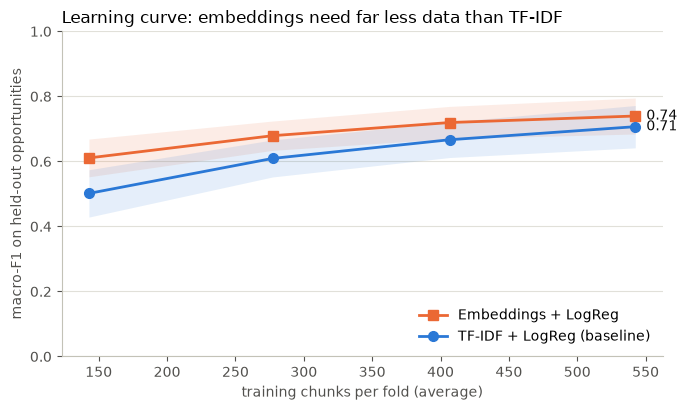

In [19]:
# ---- Learning curve: would more annotated data help? ----
# For each CV fold, train on a random 25 / 50 / 75 / 100 % of that fold's training
# *opportunities* (whole calls, never single chunks, same logic as the grouped CV), then
# score on the untouched test fold. Each smaller share is drawn 5 times with different
# seeds and averaged, so one lucky or unlucky subset doesn't decide the point.
import matplotlib.pyplot as plt
from sklearn.base import clone

FRACTIONS = [0.25, 0.5, 0.75, 1.0]
N_DRAWS = 5

# the two tuned models from above, with the hyperparameters their grid searches picked
curve_models = {
    "TF-IDF + LogReg (baseline)": (grid.best_estimator_, X_text),
    "Embeddings + LogReg": (emb_grid.best_estimator_, X_emb),
}

curve_rows = []
for name, (estimator, X_all) in curve_models.items():
    for frac in FRACTIONS:
        for fold, (train_idx, test_idx) in enumerate(cv.split(X_text, y, groups)):
            for draw in range(N_DRAWS if frac < 1 else 1):  # 100% has only one possible "subset"
                rng = np.random.default_rng(draw)
                train_opps = groups.iloc[train_idx].unique()
                kept = rng.choice(train_opps, size=round(frac * len(train_opps)), replace=False)
                sub_idx = train_idx[groups.iloc[train_idx].isin(kept).to_numpy()]

                model = clone(estimator).fit(X_all[sub_idx] if isinstance(X_all, np.ndarray) else X_all.iloc[sub_idx],
                                             y.iloc[sub_idx])
                X_test = X_all[test_idx] if isinstance(X_all, np.ndarray) else X_all.iloc[test_idx]
                curve_rows.append({
                    "model": name, "fraction": frac, "train_chunks": len(sub_idx),
                    # zero_division=0: a small subset can miss a class entirely - that
                    # class then scores 0, which is exactly the cost of too little data
                    "macro_f1": f1_score(y.iloc[test_idx], model.predict(X_test),
                                         labels=LABEL_ORDER, average="macro", zero_division=0),
                })

curve = (pd.DataFrame(curve_rows)
         .groupby(["model", "fraction"])
         .agg(train_chunks=("train_chunks", "mean"), mean_f1=("macro_f1", "mean"), std_f1=("macro_f1", "std"))
         .reset_index())
print(curve.round(3).to_string(index=False))

# ---- plot: one line per model, shaded band = +/- 1 std across folds and draws ----
COLORS = {"TF-IDF + LogReg (baseline)": "#2a78d6", "Embeddings + LogReg": "#eb6834"}  # validated pair (CVD-safe)
MARKERS = {"TF-IDF + LogReg (baseline)": "o", "Embeddings + LogReg": "s"}               # second cue beside colour

fig, ax = plt.subplots(figsize=(7, 4.2))
for name, part in curve.groupby("model"):
    ax.fill_between(part["train_chunks"], part["mean_f1"] - part["std_f1"], part["mean_f1"] + part["std_f1"],
                    color=COLORS[name], alpha=0.12, linewidth=0)
    ax.plot(part["train_chunks"], part["mean_f1"], color=COLORS[name], marker=MARKERS[name],
            markersize=7, linewidth=2, label=name)
    last = part.iloc[-1]  # direct label at the line end, in text colour (not the series colour)
    ax.annotate(f"{last['mean_f1']:.2f}", (last["train_chunks"], last["mean_f1"]),
                xytext=(8, 0), textcoords="offset points", va="center", color="#0b0b0b", fontsize=10)

ax.set_xlabel("training chunks per fold (average)", color="#52514e")
ax.set_ylabel("macro-F1 on held-out opportunities", color="#52514e")
ax.set_title("Learning curve: embeddings need far less data than TF-IDF", loc="left", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)  # recessive horizontal grid only
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# Reading it:
#  - embeddings with half the data (~277 chunks, 0.68) roughly match TF-IDF with all of
#    it (0.71), and the gap is widest at the smallest size
#  - the embeddings curve flattens (+0.07, then +0.04, then +0.02 per step): the model is
#    close to what this label set supports - human-vs-pre-label agreement on round 2
#    was 74% (kappa 0.675), and the best model's accuracy is 72%
#  - history: this same curve on round 1's 292 chunks is what motivated round 2


## Conclusion

*Snapshot of the results on the committed annotation file (678 chunks); everything above is deterministic, and model 4 reads its answers from the cache. Round-1 scores (292 chunks) in brackets.*

| Model | Mean macro-F1 (5 folds) |
|---|---|
| TF-IDF + LogReg (baseline) | 0.707 *(0.625)* |
| TF-IDF + Linear SVM | 0.681 *(0.643)* |
| **Embeddings + LogReg** | **0.740** *(0.723)* |
| *OpenAI LLM, few-shot (reference)* | *0.767 (0.766)* |

**Answer to RQ1: yes.** A trained model identifies the eligibility requirement stated in a chunk with 0.740 macro-F1 across 9 classes (72% accuracy), validated on opportunities it never saw during training.

**Chosen model: embeddings + Logistic Regression.**
- Best trained model, ahead of the TF-IDF baseline on 4 of 5 folds.
- Its advantage is largest where data is scarce (learning curve) and on the classes TF-IDF can't separate by counting words, such as DISCIPLINE (0.67 → 0.74).
- LogReg instead of an SVM on the embeddings: slightly better (0.740 vs 0.722), and it gives probabilities, so the product can send low-confidence labels to human review.

**What more data changed.** Every trained model improved, TF-IDF the most (+0.08). The TF-IDF SVM, narrowly ahead of the baseline at 292 chunks, fell behind it on all 5 folds at 678: its earlier win was small-sample noise.

**The LLM reference.** A local model with zero per-call cost and fully repeatable answers gets within about 0.03 macro-F1 of a hosted LLM that needed no training data, and beats it on 3 of 5 folds. That puts a number on the product's design choice: about 0.03 F1 traded for determinism, zero cost and local execution.

**Limitations.**
- Label consistency sets the ceiling: on a blind review of round 2, the human reviewer agreed with the LLM-applied pre-labels 74% of the time (Cohen's kappa 0.675, "substantial"), and the best model's accuracy (72%) is already close to that. The disagreements cluster on the EDUCATION / STUDENT_STATUS / CAREER_STAGE and organisation-type / RESIDENCE boundaries.
- Most labels were applied by an LLM session following the guidelines and then reviewed in part, so the LLM reference may still be slightly flattered (agreement bias), but kappa shows the labels are not an LLM's private convention.
- EDUCATION stays thin (15 chunks): pure degree requirements are rare in this corpus.
- Only chunks the model got wrong were audited after round 1, so round-1 scores are slightly optimistic.
- Section headings were excluded from the training data, so the production chunker must drop them before classification.
- The learning curve is flattening: more of the same data would add little; clearer class boundaries would help more.

**Next step.** Fit the chosen model on all 678 chunks and save it for the deterministic eligibility engine (below).

Full reasoning, per-step decisions and caveats: `flows.md` ("Eligibility classifier") and `ANNOTATION_GUIDELINES.md` §6.


## Final model

Cross-validation chose the model and its hyperparameters; the version the product uses is refit on **all 678 chunks**, since no data needs to be held back any more. Its expected quality is the CV estimate above (0.740 macro-F1): no score computed on the training data itself would mean anything.

Saved to `artifacts/`:
- `eligibility_classifier.joblib` — the fitted Logistic Regression (embeddings in, label + probabilities out)
- `eligibility_classifier.json` — what is needed to use it correctly: the embedding model it expects, its hyperparameters, labels, training-set size, CV score and library versions

In [20]:
# ---- Final model: refit the chosen model on every labeled chunk ----
import json
from datetime import date

import joblib
import sklearn
import fastembed

# the configuration CV selected (C=10), refit from scratch on all 678 chunks.
# (GridSearchCV's refit already did the same; clone + fit makes the step explicit and
# independent of how the grid search object was configured.)
final_model = clone(emb_grid.best_estimator_).fit(X_emb, y)

ARTIFACT_DIR = os.path.join(REPO_ROOT, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)
MODEL_PATH = os.path.join(ARTIFACT_DIR, "eligibility_classifier.joblib")
META_PATH = os.path.join(ARTIFACT_DIR, "eligibility_classifier.json")

joblib.dump(final_model, MODEL_PATH)

# the classifier only reads 768-number vectors: whoever loads it must embed text with the
# SAME model, or the predictions are meaningless - so that is recorded next to it
metadata = {
    "task": "RQ1 eligibility classification of requirements_text_en chunks",
    "embedding_model": EMBEDDING_MODEL,
    "embedding_dim": int(X_emb.shape[1]),
    "classifier": "LogisticRegression",
    "params": {k.removeprefix("clf__"): v for k, v in emb_grid.best_params_.items()},
    "class_weight": "balanced",
    "labels": final_model.classes_.tolist(),
    "n_train_chunks": int(len(y)),
    "n_train_opportunities": int(groups.nunique()),
    "training_data": "dataset/labels/eligibility_annotations.csv",
    "cv": "5-fold StratifiedGroupKFold by opportunity_id, random_state=42",
    "cv_macro_f1": round(float(emb_grid.best_score_), 4),
    "trained_on": date.today().isoformat(),
    "versions": {"scikit-learn": sklearn.__version__, "fastembed": fastembed.__version__},
}
with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"saved {os.path.relpath(MODEL_PATH, REPO_ROOT)} and {os.path.relpath(META_PATH, REPO_ROOT)}")
metadata

saved artifacts/eligibility_classifier.joblib and artifacts/eligibility_classifier.json


{'task': 'RQ1 eligibility classification of requirements_text_en chunks',
 'embedding_model': 'BAAI/bge-base-en-v1.5',
 'embedding_dim': 768,
 'classifier': 'LogisticRegression',
 'params': {'C': 10},
 'class_weight': 'balanced',
 'labels': ['AGE',
  'CAREER_STAGE',
  'DISCIPLINE',
  'EDUCATION',
  'NATIONALITY',
  'NONE',
  'OTHER_ELIGIBILITY',
  'RESIDENCE',
  'STUDENT_STATUS'],
 'n_train_chunks': 678,
 'n_train_opportunities': 217,
 'training_data': 'dataset/labels/eligibility_annotations.csv',
 'cv': '5-fold StratifiedGroupKFold by opportunity_id, random_state=42',
 'cv_macro_f1': 0.7396,
 'trained_on': '2026-09-29',
 'versions': {'scikit-learn': '1.9.1', 'fastembed': '0.8.1'}}

In [21]:
# Sanity check: reload from disk (as the product will) and classify unseen sentences.
# joblib files are pickles, which can run code when loaded - only ever load this one,
# produced by this notebook, never a file from an untrusted source.
loaded = joblib.load(MODEL_PATH)

# the reloaded model must reproduce the in-memory one exactly
assert (loaded.predict(X_emb) == final_model.predict(X_emb)).all()

examples = [
    "Applicants must be resident in Scotland.",
    "The residency is open to artists under the age of 35.",
    "We welcome applications from painters, sculptors and printmakers.",
    "The selected artist will present their work at the end of the residency.",
]
ex_emb = np.array(list(embedder.embed(examples)))
ex_proba = loaded.predict_proba(ex_emb)

pd.DataFrame({
    "chunk": examples,
    "label": loaded.classes_[ex_proba.argmax(axis=1)],
    "confidence": ex_proba.max(axis=1).round(2),
})

,chunk,label,confidence
0,Applicants must be resident in Scotland.,RESIDENCE,0.91
1,The residency is open to artists under the age of 35.,AGE,0.75
2,"We welcome applications from painters, sculptors and printmakers.",DISCIPLINE,0.68
3,The selected artist will present their work at the end of the residency.,CAREER_STAGE,0.38
